In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import utils as ut
import seaborn as sns
import datetime
import math
import matplotlib.pyplot as plt
from skfolio.datasets import load_sp500_dataset, load_sp500_implied_vol_dataset
from skfolio.preprocessing import prices_to_returns
from scipy.stats import pearsonr, spearmanr
import pingouin as pg
from statsmodels.tsa.stattools import coint


plt.style.use('seaborn-v0_8')

# Consistent color mapping
colors = {
    'Classic':      '#1f77b4',  # muted blue
    'Parkinson':    '#ff7f0e',  # orange
    'Garman-Klass': '#2ca02c',  # green
    'Implied':      '#d62728',  # red
    'VIX':          '#9467bd',  # purple
}

sns.set_theme(style='darkgrid')
sns.set_context('talk')

In [2]:
ticker = "AAPL"
start_date = "2010-01-01"
end_date = datetime.datetime.now().strftime("%Y-%m-%d")
df = yf.download(ticker, start=start_date, end=end_date)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
garman_klass_volatility = ut.calculate_garman_klass_estimator(df)
print(f"Garman-Klass Volatility Estimate: {garman_klass_volatility}")

parkinsons_volatility = ut.calculate_parkinsons_estimator(df)
print(f"Parkinson's Volatility Estimate: {parkinsons_volatility}")

Garman-Klass Volatility Estimate: Ticker
AAPL    0.014212
dtype: float64
Parkinson's Volatility Estimate: Ticker
AAPL    0.87878
dtype: float64


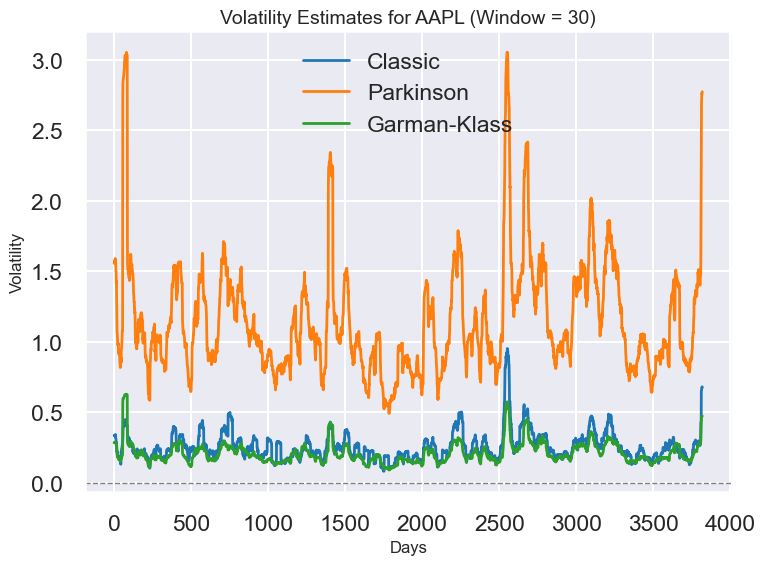

In [4]:
# Plot for a window size of 30
window_size = 30
# get daily volatility estimates 
classic, park, gk = ut.get_rolling_window_estimates(df, window_size)
# annualize
annualized_classic = np.sqrt(252) * np.array(classic)
annualized_park = np.sqrt(252) * np.array(park)
annualized_gk = np.sqrt(252) * np.array(gk)

ut.plot_rolling_window_estimate(annualized_classic, annualized_park, annualized_gk, window_size, ticker)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1398: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


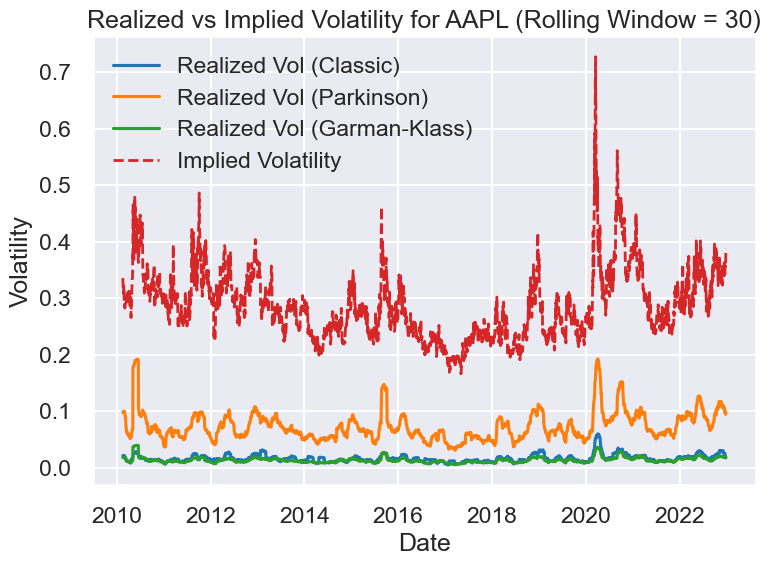

In [5]:
implied_vol = load_sp500_implied_vol_dataset()

ticker_data = df
ticker_impl_vol = implied_vol[ticker]

ticker_data = ticker_data.loc["2010-01-01":end_date]
ticker_impl_vol = ticker_impl_vol.loc["2010-01-01":end_date]

classic_measures, park_estimates, garman_estimates = ut.get_rolling_window_estimates(ticker_data, window_size)

# alignment
aligned = ticker_data.index[window_size - 1:]
realized_vol_df = pd.DataFrame({
    'Classic': classic_measures,
    'Parkinson': park_estimates,
    'Garman-Klass': garman_estimates
}, index=aligned)

common_index = realized_vol_df.index.intersection(ticker_impl_vol.index)
realized_vol_df = realized_vol_df.loc[common_index]
aligned_impl_vol = ticker_impl_vol.loc[common_index]

plt.figure(figsize=(8, 6))
plt.plot(realized_vol_df.index, realized_vol_df['Classic'], label='Realized Vol (Classic)', color=colors['Classic'])
plt.plot(realized_vol_df.index, realized_vol_df['Parkinson'], label="Realized Vol (Parkinson)", color=colors['Parkinson'])
plt.plot(realized_vol_df.index, realized_vol_df['Garman-Klass'], label='Realized Vol (Garman-Klass)', color=colors['Garman-Klass'])
plt.plot(aligned_impl_vol.index, aligned_impl_vol, label='Implied Volatility', linestyle='--', linewidth=2, color=colors['Implied'])

plt.title(f'Realized vs Implied Volatility for {ticker} (Rolling Window = {window_size})')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 4 : Implied Volatility Data and VIX Estimation 

Set initial variables 

In [6]:
spx_symbol = "^SPX"
today = datetime.datetime.strptime("2025-03-05", "%Y-%m-%d")
end_date = today
start_date = end_date - datetime.timedelta(days=365) 

In [7]:
spx_data = yf.download(spx_symbol, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [8]:
last_bus_day = spx_data.index[-1]
print(last_bus_day)

2025-03-04 00:00:00


In [9]:
vix_data = yf.download("^VIX", start=last_bus_day, end=last_bus_day + datetime.timedelta(days=1))  

[*********************100%***********************]  1 of 1 completed


In [10]:
closest_expiry_date = ut.find_closest_expiry(spx_symbol, today)
closest_expiry_date = closest_expiry_date.strftime('%Y-%m-%d')
print(closest_expiry_date)

2025-04-21


In [11]:
expiry_datetime = datetime.datetime.strptime(closest_expiry_date, "%Y-%m-%d")
days_to_expiry = (expiry_datetime - last_bus_day.to_pydatetime()).days
T = days_to_expiry / 365.0  # Time to expiration in years
print(f"Days to expiration: {days_to_expiry}")
print(f"T (years): {T:.4f}")

Days to expiration: 48
T (years): 0.1315


In [12]:
S0 = float(spx_data['Close'].iloc[-1])  
print(f"Spot Price : {S0}")
F0 = S0 * np.exp(0.02 * (T))
print(f"forward price : {F0}") 

Spot Price : 5778.14990234375
forward price : 5793.367231171682


/var/folders/zd/05ndgbcd4k35_hn1kps4c8sr0000gn/T/ipykernel_46845/4272605967.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(spx_data['Close'].iloc[-1])


In [13]:
closest_expiry_date = ut.find_closest_expiry(spx_symbol, today)
closest_expiry_date = closest_expiry_date.strftime('%Y-%m-%d')
print(closest_expiry_date)

2025-04-21


In [14]:
spx_ticker = yf.Ticker(spx_symbol)
chain = spx_ticker.option_chain(closest_expiry_date)
calls_df = chain.calls.copy()
puts_df = chain.puts.copy()

In [15]:
puts_otm = puts_df[puts_df['strike'] < F0].copy()
calls_otm = calls_df[calls_df['strike'] > F0].copy()

print(ut.VIX_estimator(puts_otm, calls_otm, F0))

27.046255302281164


In [16]:
vix_data = yf.download("^VIX", start=last_bus_day, end=last_bus_day + datetime.timedelta(days=1))
print(vix_data['Close'])

[*********************100%***********************]  1 of 1 completed

Ticker       ^VIX
Date             
2025-03-04  23.51


d)

[*********************100%***********************]  1 of 1 completed
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1398: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


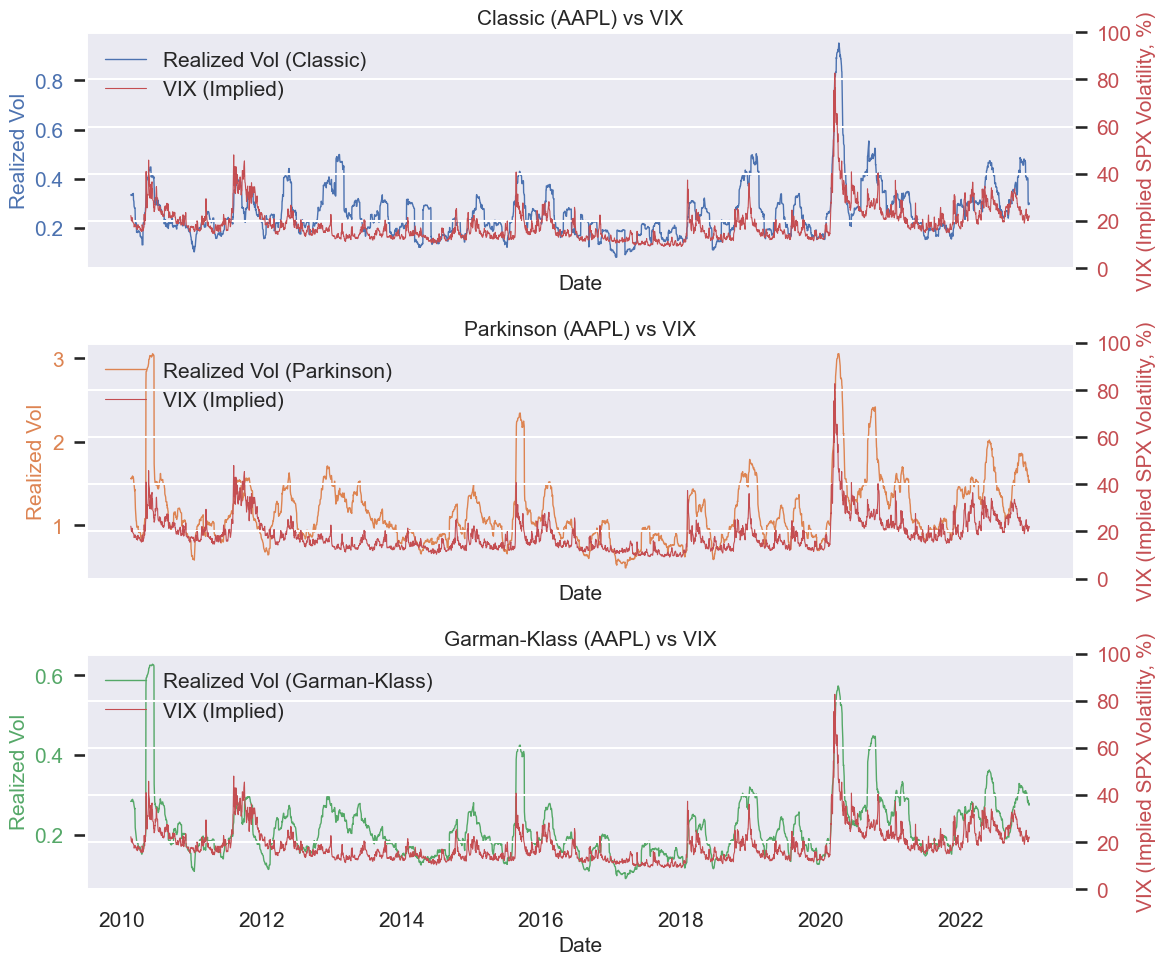

In [25]:
vix_data = yf.download("^VIX", start=ticker_data.index[0], end=ticker_data.index[-1])
vix_data.columns = vix_data.columns.droplevel('Ticker')

# Annualize
realized_vol_annualized = realized_vol_df.copy()
realized_vol_annualized[['Classic', 'Parkinson', 'Garman-Klass']] *= np.sqrt(252)
combined_df = pd.concat([
    realized_vol_annualized,
    vix_data['Close'] 
], axis=1).dropna()

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

estimators = ['Classic', 'Parkinson', 'Garman-Klass']
colors = ['C0', 'C1', 'C2']

for ax, est, color in zip(axs, estimators, colors):
    ax.plot(combined_df.index, combined_df[est], label=f"Realized Vol ({est})",
            color=color, linewidth=1)
    ax.set_ylabel("Realized Vol", color=color, fontsize=15)
    ax.tick_params(axis='y', labelcolor=color, labelsize=15)
    ax.set_xlabel("Date", fontsize=15)
    ax.tick_params(axis='x', labelsize=15)
    ax.grid(False)
    ax.set_title(f"{est} ({ticker}) vs VIX", fontsize=15)

    ax2 = ax.twinx()
    ax2.plot(combined_df.index, combined_df['Close'], label="VIX (Implied)",
             color='C3', linewidth=0.8)
    ax2.set_ylabel("VIX (Implied SPX Volatility, %)", color='C3', fontsize=15)
    ax2.set_ylim(0, 100)
    ax2.tick_params(axis='y', labelcolor='C3', labelsize=15)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=15)

plt.tight_layout()
plt.show()


Cointegration is designed for nonstationary (I(1)) series that wander without reverting to a mean but maintain a stable linear relationship.
The data appears to revert back to a mean and exhibit stationary like behaviour.
Stationary is constant mean and variance over time. Nonstationary is time varying mean (trends) / de/increasing variance

Sidenote: Pearson's correlation coefficient is parametric and Spearman's rho is non-parametric. Spearman is computed in the same way, except we substitute all values with their ranks.

Remember that estimators are based on a 30 day rolling window. Does this affect test results? Maybe

Pearson correlation assumes data isn’t trending or nonstationary in a way that produces a spurious correlation. Volatility can exhibit trends, volatility clustering, and strong autocorrelation.

First we perform a stationary check using an ADF test

In [18]:
# Run ADF test on each column
for col in ['Classic','Parkinson','Garman-Klass','Close']:
    ut.adf_test(combined_df[col], name=col)

=== Augmented Dickey-Fuller Test for Classic ===
ADF Statistic: -4.6903
p-value: 0.000088
Critical Values 1%, -3.4324
Critical Values 5%, -2.8624
Critical Values 10%, -2.5672
--------------------------------------

=== Augmented Dickey-Fuller Test for Parkinson ===
ADF Statistic: -7.0707
p-value: 0.000000
Critical Values 1%, -3.4324
Critical Values 5%, -2.8624
Critical Values 10%, -2.5672
--------------------------------------

=== Augmented Dickey-Fuller Test for Garman-Klass ===
ADF Statistic: -7.2407
p-value: 0.000000
Critical Values 1%, -3.4324
Critical Values 5%, -2.8624
Critical Values 10%, -2.5672
--------------------------------------

=== Augmented Dickey-Fuller Test for Close ===
ADF Statistic: -4.7634
p-value: 0.000064
Critical Values 1%, -3.4324
Critical Values 5%, -2.8624
Critical Values 10%, -2.5672
--------------------------------------



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_asarray.py:127: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  arr = array(a, dtype=dtype, order=order, copy=None, subok=subok)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_asarray.py:127: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  arr = array(a, dtype=dtype, order=order, copy=None, subok=subok)


Since the p-value is well below typical significance levels (e.g., 0.05) and the ADF statistic is below the critical values at 1%, 5%, and 10%, the Classic realized volatility series is stationary

Now we perform remaining tests.
Add to report: can the type of estimator affect correlation? Interesting to add


Pingouin Pearson - Classic vs VIX:
            n         r         CI95%  p-val BF10  power
pearson  3241  0.664029  [0.64, 0.68]    0.0  inf    1.0

Pingouin Spearman - Classic vs VIX:
             n         r         CI95%  p-val  power
spearman  3241  0.610242  [0.59, 0.63]    0.0    1.0


/var/folders/zd/05ndgbcd4k35_hn1kps4c8sr0000gn/T/ipykernel_46845/989683116.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  combined_df[col_name] = combined_df[est].rolling(rolling_window).corr(combined_df['Close'])
/var/folders/zd/05ndgbcd4k35_hn1kps4c8sr0000gn/T/ipykernel_46845/989683116.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  combined_df[col_name] = combined_df[est].rolling(rolling_window).corr(combined_df['Close'])


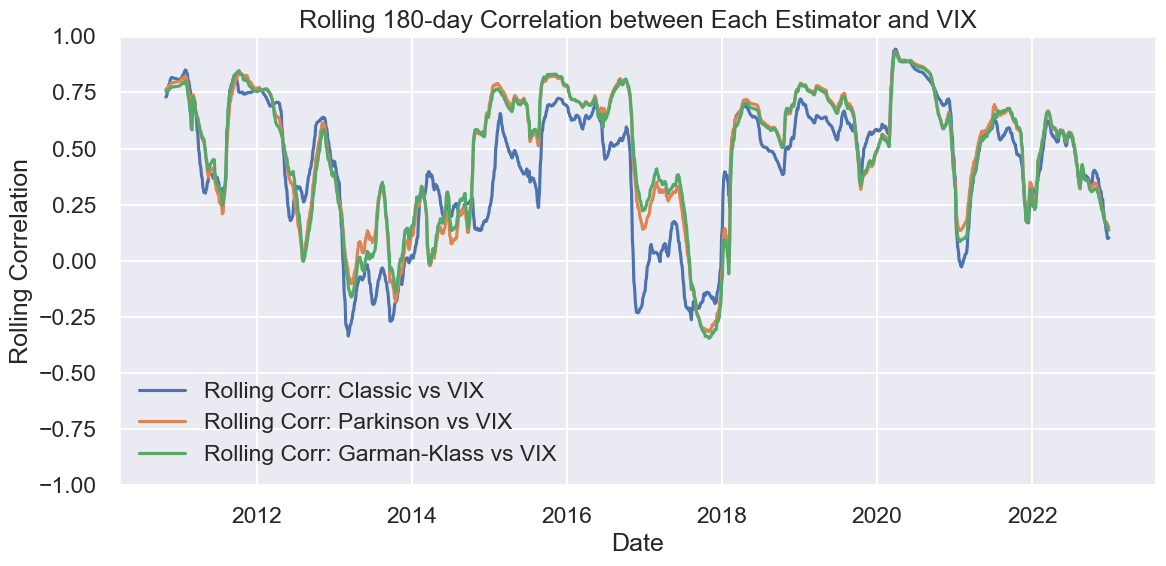


Cointegration Test: Classic vs VIX:
  Test Statistic: -6.1898
  p-value: 0.000001
  Critical Values: [-3.89982341 -3.33801648 -3.04575927]

Cointegration Test: Parkinson vs VIX:
  Test Statistic: -8.1304
  p-value: 0.000000
  Critical Values: [-3.89982341 -3.33801648 -3.04575927]

Cointegration Test: Garman-Klass vs VIX:
  Test Statistic: -8.3340
  p-value: 0.000000
  Critical Values: [-3.89982341 -3.33801648 -3.04575927]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_asarray.py:127: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  arr = array(a, dtype=dtype, order=order, copy=None, subok=subok)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_asarray.py:127: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  arr = array(a, dtype=dtype, order=order, copy=None, subok=subok)


In [19]:
pairs = [('Classic', 'Close'),
         ('Parkinson', 'Close'),
         ('Garman-Klass', 'Close')]

x_classic = combined_df['Classic'].to_numpy()
y_vix = combined_df['Close'].to_numpy()

# Pearson correlation 
pearson_results = pg.corr(x_classic, y_vix, method='pearson')
print("Pingouin Pearson - Classic vs VIX:")
print(pearson_results)

# Spearman correlation 
spearman_results = pg.corr(x_classic, y_vix, method='spearman')
print("\nPingouin Spearman - Classic vs VIX:")
print(spearman_results)

# compute rolling correlations for 180 day window
rolling_window = 180 
for est, _ in pairs:
    col_name = f'RollingCorr_{est}'
    combined_df[col_name] = combined_df[est].rolling(rolling_window).corr(combined_df['Close'])

plt.figure(figsize=(12, 6))
for est in ['Classic', 'Parkinson', 'Garman-Klass']:
    plt.plot(combined_df.index, combined_df[f'RollingCorr_{est}'], label=f'Rolling Corr: {est} vs VIX')
plt.title(f'Rolling {rolling_window}-day Correlation between Each Estimator and VIX')
plt.xlabel("Date")
plt.ylabel("Rolling Correlation")
plt.ylim(-1, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# cointegration Tests
for est, vix in pairs:
    coint_t, p_value, crit_values = coint(combined_df[est], combined_df['Close'])
    print(f"\nCointegration Test: {est} vs VIX:")
    print(f"  Test Statistic: {coint_t:.4f}")
    print(f"  p-value: {p_value:.6f}")
    print(f"  Critical Values: {crit_values}")


- Rolling Window Overlap: The realized vol is already a 30-day rolling measure, so consecutive points share 29 days of data. This introduces serial correlation, making significance p-values a bit over-optimistic.
- Asset vs. Index: VIX is an index of implied vol on the S&P 500, whereas your realized vol is for MSFT. A high correlation might exist if MSFT moves in sync with the broader market; if not, correlation might be lower.
- Nonstationary Data: Volatility often exhibits clustering. ADF tests might show borderline stationarity. If the series is heavily trending or has strong GARCH effects, correlation can be driven by those factors.
Lead-Lag: Sometimes the VIX leads realized volatility. You can shift your realized vol series forward by a few days to see if correlation improves.

In [20]:
spx = yf.download("^SPX", start=ticker_data.index[0], end=ticker_data.index[-1])
spx['Return'] = spx['Close'].pct_change()

# compute 30‑day realized volatility and annualize by ×252
T = 30
classic_vols, _, _ = ut.get_rolling_window_estimates(spx, T)
# These are daily (unannualized) vol estimates for windows [0:T],[1:T+1],…
# Align them to the end‐of‐window date:
rv_dates = spx.index[T-1:]
spx_rv = pd.Series(classic_vols, index=rv_dates)
spx['RealizedVar'] = (spx_rv ** 2) * 252 # square because it's variance

# compute daily change of VIX
vix = yf.download("^VIX", start=spx.index[0], end=spx.index[-1])
vix['dVIX'] = vix['Close'].diff()

df = pd.concat([
    spx['Return'],
    vix['dVIX'],
    spx['RealizedVar']
], axis=1).dropna()
df.columns = ['Return', 'dVIX', 'RealizedVar']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [21]:
# Model 1
modA = ut.run_ols(df['Return'], df['dVIX'])
print("Return ~ dVIX")
print(modA.summary())

Return ~ dVIX
                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     1148.
Date:                Fri, 18 Apr 2025   Prob (F-statistic):          3.33e-220
Time:                        13:24:22   Log-Likelihood:                 13785.
No. Observations:                3816   AIC:                        -2.757e+04
Df Residuals:                    3814   BIC:                        -2.755e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      

In [22]:
# Model 2
modB = ut.run_ols(df['Return'], df['RealizedVar'])
print(" Return ~ RealizedVar")
print(modB.summary())

 Return ~ RealizedVar
                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                    0.4168
Date:                Fri, 18 Apr 2025   Prob (F-statistic):              0.519
Time:                        13:24:22   Log-Likelihood:                 11787.
No. Observations:                3816   AIC:                        -2.357e+04
Df Residuals:                    3814   BIC:                        -2.356e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0003      

In [23]:
# Model 3
modC = ut.run_ols(df['Return'], df[['dVIX','RealizedVar']])
print("Return ~ dVIX + RealizedVar")
print(modC.summary())

Return ~ dVIX + RealizedVar
                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     588.0
Date:                Fri, 18 Apr 2025   Prob (F-statistic):          2.69e-223
Time:                        13:24:22   Log-Likelihood:                 13785.
No. Observations:                3816   AIC:                        -2.756e+04
Df Residuals:                    3813   BIC:                        -2.755e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0005